In [3]:
!pip install xgboost

In [4]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_excel("DF_FINAL.xlsx")

df.head()

calles_base = [
        "Calle Alberto Aguilera",
        "Calle Atocha",
        "Calle Gran Vía",
        "Calle Hortaleza",
        "Calle Mayor",
        "Calle Princesa",
        "Paseo Infanta Isabel",
        "Paseo de El Prado"
]

calles_oeste = []

for base in calles_base:
    for col in df.columns:
        if base in col:
            calles_oeste.append(col)

L = 3  # número de lags

X = pd.DataFrame()

for street in calles_oeste:
    for lag in range(1, L + 1):
        X[f"{street}_t-{lag}"] = df[street].shift(lag)

# Variables externas reales
X["AEMET_tmed"] = df["AEMET_tmed"]
X["AEMET_prec"] = df["AEMET_prec"]
X["dia_semana"] = df["dia_semana"]
X["festivo"] = df["festivo"]

# Convertir variables categóricas a numéricas
X["dia_semana"] = X["dia_semana"].map({
    "lunes": 0,
    "martes": 1,
    "miércoles": 2,
    "jueves": 3,
    "viernes": 4,
    "sábado": 5,
    "domingo": 6
})

X["festivo"] = X["festivo"].map({
    "no": 0,
    "sí": 1
})


y_col = [col for col in df.columns if "Calle Alberto Aguilera" in col][0]
y = df[y_col]

# Limpiar NaNs
X = X.dropna()
y = y.loc[X.index]

In [6]:
# División temporal (80% train, 20% test)
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape, X_test.shape)

(15376, 43) (3845, 43)


In [7]:
with pd.ExcelWriter("dataset_XGBoost_AlbertoAguilera.xlsx") as writer:
    X_train.to_excel(writer, sheet_name="X_train")
    X_test.to_excel(writer, sheet_name="X_test")
    y_train.to_excel(writer, sheet_name="y_train")
    y_test.to_excel(writer, sheet_name="y_test")

In [8]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [9]:
y_pred = model.predict(X_test)
# Predicción próxima hora
X_next = X.iloc[[-1]]
y_next = model.predict(X_next)

print("Predicción tráfico en Alberto Aguilera (E-O) próxima hora:", y_next[0])

Predicción tráfico en Alberto Aguilera (E-O) próxima hora: 385.45413


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 88.30
RMSE: 186.17
MAPE: 10.80%


In [11]:
importances = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(10))

Calle Alberto Aguilera_O-E_t-1    0.607199
Calle Alberto Aguilera_E-O_t-1    0.194498
Paseo de El Prado_S-N_t-3         0.019085
Paseo de El Prado_S-N_t-1         0.017313
Calle Atocha_E-O_t-3              0.011179
Calle Alberto Aguilera_O-E_t-3    0.010411
Paseo Infanta Isabel_E-O_t-3      0.010402
Calle Princesa_S-N_t-3            0.009266
Calle Mayor_O-E_t-3               0.008591
dia_semana                        0.007492
dtype: float32


In [12]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=0,
    n_jobs=-1,
    scoring="neg_mean_absolute_error"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

perm_df.head(10)


,feature,importance
3,Calle Alberto Aguilera_O-E_t-1,217.126253
0,Calle Alberto Aguilera_E-O_t-1,186.107063
4,Calle Alberto Aguilera_O-E_t-2,8.460191
5,Calle Alberto Aguilera_O-E_t-3,6.061901
38,Paseo de El Prado_S-N_t-3,5.394977
36,Paseo de El Prado_S-N_t-1,4.702813
29,Paseo Infanta Isabel_E-O_t-3,4.040530
2,Calle Alberto Aguilera_E-O_t-3,3.774663
1,Calle Alberto Aguilera_E-O_t-2,3.473496
41,dia_semana,3.226412


In [13]:
top_k = 8
top_features = perm_df.head(top_k)
top_features


,feature,importance
3,Calle Alberto Aguilera_O-E_t-1,217.126253
0,Calle Alberto Aguilera_E-O_t-1,186.107063
4,Calle Alberto Aguilera_O-E_t-2,8.460191
5,Calle Alberto Aguilera_O-E_t-3,6.061901
38,Paseo de El Prado_S-N_t-3,5.394977
36,Paseo de El Prado_S-N_t-1,4.702813
29,Paseo Infanta Isabel_E-O_t-3,4.040530
2,Calle Alberto Aguilera_E-O_t-3,3.774663


In [14]:
top_streets = (
    top_features["feature"]
    .str.split("_")
    .str[0]
    .value_counts()
)
top_streets

feature
Calle Alberto Aguilera    5
Paseo de El Prado         2
Paseo Infanta Isabel      1
Name: count, dtype: int64

In [15]:
from pathlib import Path

# Cambiar estos dos valores en cada notebook
modelo = "XGBoost"
calle = "Calle Alberto Aguilera"

# Carpeta donde se guardarán las importancias
output_dir = Path("importancias_variables")
output_dir.mkdir(exist_ok=True)

# Guardar todas las variables, no solo el top 10
perm_df_export = perm_df.copy()
perm_df_export["modelo"] = modelo
perm_df_export["calle"] = calle

# Nombre limpio para el archivo
nombre_archivo = f"{modelo}_{calle}".replace(" ", "_").replace("á", "a").replace("é", "e")
nombre_archivo = nombre_archivo.replace("í", "i").replace("ó", "o").replace("ú", "u")

perm_df_export.to_csv(output_dir / f"{nombre_archivo}.csv", index=False)

print(f"Archivo guardado: {output_dir / f'{nombre_archivo}.csv'}")

Archivo guardado: importancias_variables\XGBoost_Calle_Alberto_Aguilera.csv


In [16]:
calle_objetivo = "Calle Alberto Aguilera"   # cámbialo según el notebook
modelo = "XGBoost"                # opcional, para tenerlo identificado

In [17]:
import pandas as pd
import unicodedata

def normalizar_texto(texto):
    texto = str(texto).lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

def clasificar_variable(feature, calle_objetivo):
    f = normalizar_texto(feature)
    calle = normalizar_texto(calle_objetivo)

    # Variables meteorológicas
    if any(palabra in f for palabra in [
        'aemet', 'tmed', 'temp', 'temperatura', 'prec', 'precipitacion',
        'humedad', 'viento', 'presion', 'radiacion'
    ]):
        return 'Variables meteorológicas'

    # Variables de calendario
    if any(palabra in f for palabra in [
        'dia_semana', 'festivo', 'mes', 'hora', 'fin_semana'
    ]):
        return 'Variables de calendario'

    # Retardos de la propia calle
    if calle in f:
        return 'Retardos propia calle'

    # Resto de variables de tráfico
    return 'Retardos otras calles'

In [18]:
perm_df_aux = perm_df.copy()

perm_df_aux["modelo"] = modelo
perm_df_aux["calle"] = calle_objetivo

perm_df_aux["tipo_variable"] = perm_df_aux["feature"].apply(
    lambda x: clasificar_variable(x, calle_objetivo)
)

perm_df_aux.head(15)

,feature,importance,modelo,calle,tipo_variable
3,Calle Alberto Aguilera_O-E_t-1,217.126253,XGBoost,Calle Alberto Aguilera,Retardos propia calle
0,Calle Alberto Aguilera_E-O_t-1,186.107063,XGBoost,Calle Alberto Aguilera,Retardos propia calle
4,Calle Alberto Aguilera_O-E_t-2,8.460191,XGBoost,Calle Alberto Aguilera,Retardos propia calle
5,Calle Alberto Aguilera_O-E_t-3,6.061901,XGBoost,Calle Alberto Aguilera,Retardos propia calle
38,Paseo de El Prado_S-N_t-3,5.394977,XGBoost,Calle Alberto Aguilera,Retardos otras calles
36,Paseo de El Prado_S-N_t-1,4.702813,XGBoost,Calle Alberto Aguilera,Retardos otras calles
29,Paseo Infanta Isabel_E-O_t-3,4.040530,XGBoost,Calle Alberto Aguilera,Retardos otras calles
2,Calle Alberto Aguilera_E-O_t-3,3.774663,XGBoost,Calle Alberto Aguilera,Retardos propia calle
1,Calle Alberto Aguilera_E-O_t-2,3.473496,XGBoost,Calle Alberto Aguilera,Retardos propia calle
41,dia_semana,3.226412,XGBoost,Calle Alberto Aguilera,Variables de calendario


In [19]:
perm_df_aux["importance_pos"] = perm_df_aux["importance"].clip(lower=0)

In [20]:
resumen_tipos = (
    perm_df_aux
    .groupby("tipo_variable")["importance_pos"]
    .sum()
    .reset_index()
)

resumen_tipos["porcentaje"] = (
    100 * resumen_tipos["importance_pos"] / resumen_tipos["importance_pos"].sum()
)

resumen_tipos = resumen_tipos.sort_values("porcentaje", ascending=False)

resumen_tipos

,tipo_variable,importance_pos,porcentaje
1,Retardos propia calle,425.003568,90.384258
0,Retardos otras calles,40.881348,8.694116
2,Variables de calendario,3.226412,0.686152
3,Variables meteorológicas,1.107243,0.235474


In [21]:
meteo_df = perm_df_aux[perm_df_aux["tipo_variable"] == "Variables meteorológicas"] \
    .sort_values("importance", ascending=False)

meteo_df.head(20)

,feature,importance,modelo,calle,tipo_variable,importance_pos
39,AEMET_tmed,1.107243,XGBoost,Calle Alberto Aguilera,Variables meteorológicas,1.107243
40,AEMET_prec,-0.010847,XGBoost,Calle Alberto Aguilera,Variables meteorológicas,0.000000


In [22]:
meteo_total = meteo_df["importance_pos"].sum()
print("Importancia positiva acumulada de meteorología:", meteo_total)

Importancia positiva acumulada de meteorología: 1.1072425842285156


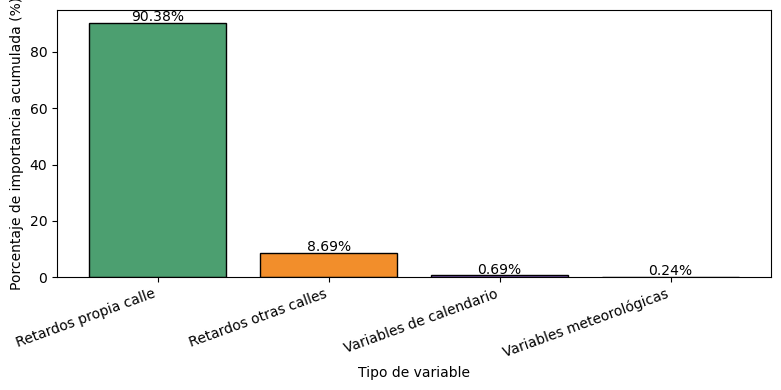

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.bar(resumen_tipos["tipo_variable"], resumen_tipos["porcentaje"],
        color=['#4C9F70', '#F28E2B', '#8E63CE', '#BDBDBD'],
        edgecolor='black')

plt.ylabel("Porcentaje de importancia acumulada (%)")
plt.xlabel("Tipo de variable")

for i, v in enumerate(resumen_tipos["porcentaje"]):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()